# Bidirectional phase-offset comparison

Goal: quantify how well mbo_utilities vs suite2p's internal `do_bidiphase` each correct for bidirectional scan-line offset on raw ScanImage data at `D:/demo/raw`.

Pipeline:
1. load raw with `mbo.imread`
2. compute per-plane scan-phase offsets with mbo
3. save two 4D TZYX tiffs: one with mbo correction baked in, one uncorrected
4. FFT image + row-row correlation diagnostics on each
5. run `lsp.pipeline` 3 ways (identical ops, only bidi source differs):
   - A: mbo-corrected input, `do_bidiphase=False`
   - B: uncorrected input, `do_bidiphase=True`   (suite2p estimates internally)
   - C: uncorrected input, `do_bidiphase=False` (baseline, no correction)
6. match cells across runs by centroid and compare F traces

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

import mbo_utilities as mbo
from mbo_utilities.analysis.phasecorr import bidir_phasecorr
import lbm_suite2p_python as lsp

raw_dir   = Path(r"D:/demo/raw")
work_dir  = Path(r"D:/demo/bidi_compare")
work_dir.mkdir(parents=True, exist_ok=True)

mbo_tiff_dir = work_dir / "tiff_mbo_corrected"
raw_tiff_dir = work_dir / "tiff_uncorrected"

res_A = work_dir / "s2p_A_mbo-on_s2p-off"
res_B = work_dir / "s2p_B_mbo-off_s2p-on"
res_C = work_dir / "s2p_C_neither"

# plane used for all diagnostics and trace comparison
ANALYSIS_PLANE = 7  # 1-based

## 1. Load raw and inspect

In [2]:
arr = mbo.imread(raw_dir)
print(f"type        : {type(arr).__name__}")
print(f"shape (TCZYX): {arr.shape}")
print(f"dtype        : {arr.dtype}")
print(f"num_frames   : {arr.num_frames}")
print(f"num_planes   : {arr.num_planes}")
print(f"fs (Hz)      : {arr.metadata.get('fs')}")
print(f"fix_phase    : {arr.fix_phase}  (method={arr.phasecorr_method}, fft={arr.use_fft})")

Counting frames:   0%|          | 0/2 [00:00<?, ?it/s]

type        : LBMArray
shape (TCZYX): (1574, 1, 14, 550, 448)
dtype        : int16
num_frames   : 1574
num_planes   : 14
fs (Hz)      : 14.0
fix_phase    : True  (method=mean, fft=True)


## 2. Compute per-plane scan-phase offsets

Use `bidir_phasecorr` directly on a time-averaged window of each plane so we see the shifts mbo would bake in. The reader itself caches this at read-time, but doing it up front lets us print/log the values.

In [3]:
# pull the raw (uncorrected) frames for offset estimation
arr.fix_phase = False
N_SAMPLE = min(500, arr.num_frames)

# (T, C, Z, Y, X) -> drop singleton C
sample = np.asarray(arr[:N_SAMPLE, 0, :, :, :])  # (T, Z, Y, X)
print("sample shape:", sample.shape)

offsets = np.zeros(arr.num_planes, dtype=float)
for z in range(arr.num_planes):
    _, off = bidir_phasecorr(
        sample[:, z],       # (T, Y, X)
        method="mean",
        use_fft=True,
        upsample=10,
        max_offset=4,
        border=4,
    )
    offsets[z] = float(off)

for z, o in enumerate(offsets, start=1):
    print(f"  plane {z:2d}: mbo offset = {o:+.2f} px")
print(f"\nmean |offset| = {np.abs(offsets).mean():.2f} px")

sample shape: (500, 14, 550, 448)
  plane  1: mbo offset = +0.70 px
  plane  2: mbo offset = +0.60 px
  plane  3: mbo offset = +0.40 px
  plane  4: mbo offset = +0.30 px
  plane  5: mbo offset = +0.10 px
  plane  6: mbo offset = +0.00 px
  plane  7: mbo offset = -0.10 px
  plane  8: mbo offset = -0.20 px
  plane  9: mbo offset = -0.30 px
  plane 10: mbo offset = -0.50 px
  plane 11: mbo offset = -0.50 px
  plane 12: mbo offset = -0.80 px
  plane 13: mbo offset = +0.50 px
  plane 14: mbo offset = +0.90 px

mean |offset| = 0.42 px


## 3. Save 4D TZYX tiffs (mbo-corrected and uncorrected)

The ScanImage reader is 5D (T,C,Z,Y,X) with C=1 for this dataset; `imwrite` with a tiff target drops the singleton channel and writes a 4D ImageJ hyperstack.

In [4]:
# --- uncorrected save ---
arr.fix_phase = False
mbo.imwrite(arr, raw_tiff_dir, ext=".tiff", overwrite=True)
print("wrote uncorrected:", list(raw_tiff_dir.glob("*.tif*")))

# --- mbo-corrected save ---
arr.fix_phase = True
arr.phasecorr_method = "mean"
arr.use_fft = True
mbo.imwrite(arr, mbo_tiff_dir, ext=".tiff", overwrite=True)
print("wrote mbo-corrected:", list(mbo_tiff_dir.glob("*.tif*")))

Writing TIFF:   0%|          | 0/22036 [00:00<?, ?pg/s]

wrote uncorrected: [WindowsPath('D:/demo/bidi_compare/tiff_uncorrected/tp00001-01574_ch01_zplane01-14_stack.tif')]


Writing TIFF:   0%|          | 0/22036 [00:00<?, ?pg/s]

wrote mbo-corrected: [WindowsPath('D:/demo/bidi_compare/tiff_mbo_corrected/tp00001-01574_ch01_zplane01-14_stack.tif')]


## 4. Diagnostics: FFT image + row-row correlation

Bidirectional misalignment puts energy at the Nyquist row frequency of the 2D FFT (bright horizontal line at fy = N/2). It also lowers the correlation between adjacent (even vs odd) rows. Check both on the mean image of the analysis plane.

median adjacent row corr (raw): 0.974
median adjacent row corr (mbo): 0.974
mbo offset used for plane 7: -0.10 px


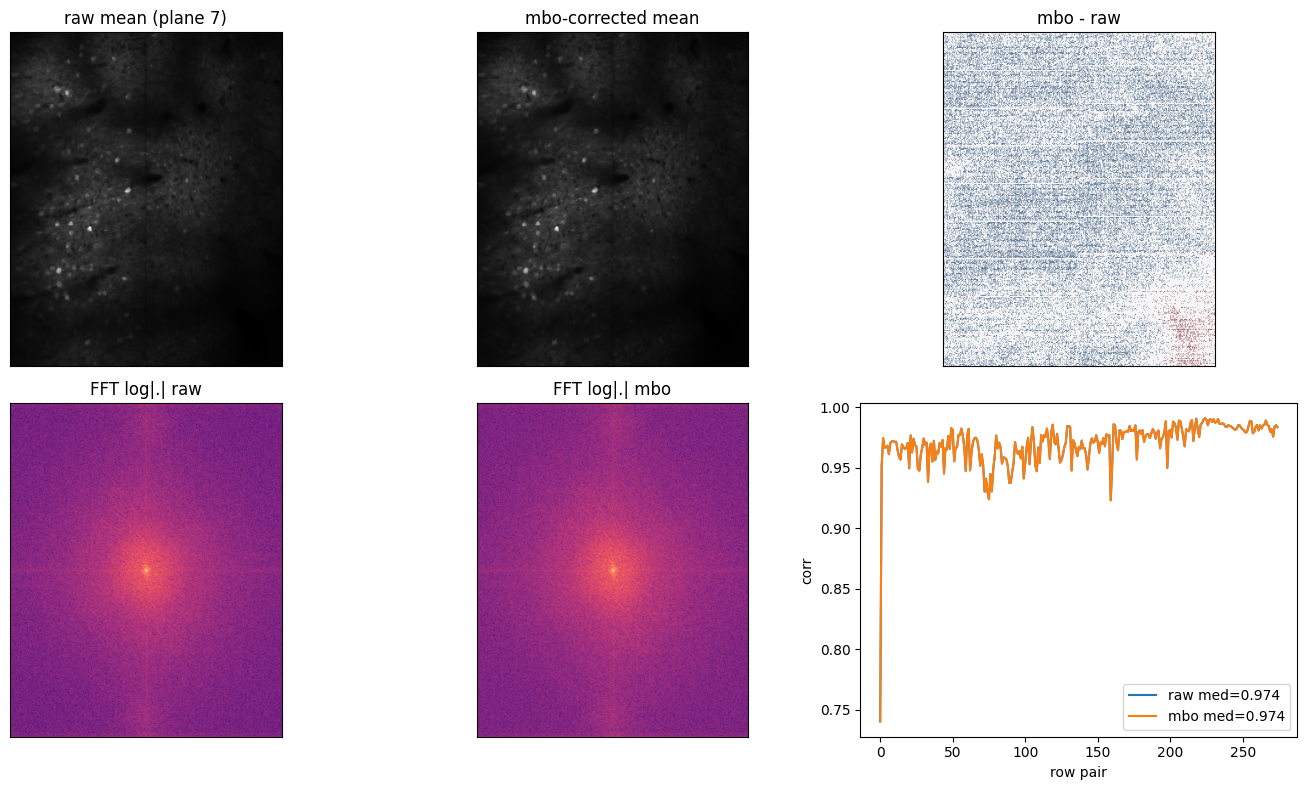

In [5]:
def fft_log_mag(img):
    """centered log-magnitude of 2D FFT."""
    F = np.fft.fftshift(np.fft.fft2(img.astype(np.float32)))
    return np.log1p(np.abs(F))

def row_row_corr(img):
    """Pearson corr between every even row and the next odd row; return (median, array)."""
    img = img.astype(np.float32)
    even = img[0:-1:2]  # 0, 2, 4, ...
    odd  = img[1::2]    # 1, 3, 5, ...
    n = min(len(even), len(odd))
    even, odd = even[:n], odd[:n]
    e = even - even.mean(axis=1, keepdims=True)
    o = odd  - odd.mean(axis=1, keepdims=True)
    num = (e * o).sum(axis=1)
    den = np.sqrt((e*e).sum(axis=1) * (o*o).sum(axis=1)) + 1e-12
    return float(np.median(num/den)), num/den

z = ANALYSIS_PLANE - 1

arr.fix_phase = False
raw_mean = np.asarray(arr[:N_SAMPLE, 0, z]).mean(axis=0)
arr.fix_phase = True
mbo_mean = np.asarray(arr[:N_SAMPLE, 0, z]).mean(axis=0)

med_raw, rc_raw = row_row_corr(raw_mean)
med_mbo, rc_mbo = row_row_corr(mbo_mean)
print(f"median adjacent row corr (raw): {med_raw:.3f}")
print(f"median adjacent row corr (mbo): {med_mbo:.3f}")
print(f"mbo offset used for plane {ANALYSIS_PLANE}: {offsets[z]:+.2f} px")

fig, ax = plt.subplots(2, 3, figsize=(14, 8))
ax[0,0].imshow(raw_mean, cmap="gray"); ax[0,0].set_title(f"raw mean (plane {ANALYSIS_PLANE})")
ax[0,1].imshow(mbo_mean, cmap="gray"); ax[0,1].set_title("mbo-corrected mean")
ax[0,2].imshow(mbo_mean.astype(np.int32) - raw_mean.astype(np.int32), cmap="RdBu_r")
ax[0,2].set_title("mbo - raw")
ax[1,0].imshow(fft_log_mag(raw_mean), cmap="magma"); ax[1,0].set_title("FFT log|.| raw")
ax[1,1].imshow(fft_log_mag(mbo_mean), cmap="magma"); ax[1,1].set_title("FFT log|.| mbo")
ax[1,2].plot(rc_raw, label=f"raw med={med_raw:.3f}")
ax[1,2].plot(rc_mbo, label=f"mbo med={med_mbo:.3f}")
ax[1,2].set_xlabel("row pair"); ax[1,2].set_ylabel("corr"); ax[1,2].legend()
for a in ax.ravel()[:5]: a.set_xticks([]); a.set_yticks([])
plt.tight_layout(); plt.show()

## 5. Run suite2p 3 ways

Same ops for all three, only the bidi settings differ. Running on a single analysis plane keeps this quick — change `planes=None` to process all planes.

In [7]:
def make_ops(do_bidiphase, bidiphase=0):
    ops = lsp.default_ops()
    ops["do_bidiphase"] = bool(do_bidiphase)
    ops["bidiphase"]    = int(bidiphase)
    ops["diameter"] = 6
    ops["anatomical_only"] = 3
    return ops

planes_sel = [ANALYSIS_PLANE]  # set to None for the full volume

In [8]:
# A: mbo correction baked in, suite2p bidi OFF
lsp.pipeline(
    input_data=mbo_tiff_dir,
    save_path=res_A,
    ops=make_ops(do_bidiphase=False, bidiphase=0),
    planes=planes_sel,
    force_reg=True,
    force_detect=True,
)

Importing suite2p packages...
Loading input to determine dimensions...
Delegating to run_volume (volumetric input detected)...
Processing 1 planes in volume (Total planes: 14)
Output: D:\demo\bidi_compare\s2p_A_mbo-on_s2p-off

--- Volume Step: Plane 7 ---
Importing suite2p packages...
Writing binary to D:\demo\bidi_compare\s2p_A_mbo-on_s2p-off\zplane07_tp00001-01574...


pynwb not installed, save_nwb, read_nwb, and nwb_to_binary will not work. Install with: pip install pynwb


  Computing dF/F...
  Computing ROI statistics...
Plotting results for 48 accepted / 2 rejected ROIs

Genering volumetric statistics...


[WindowsPath('D:/demo/bidi_compare/s2p_A_mbo-on_s2p-off/zplane07_tp00001-01574/ops.npy')]

In [9]:
# B: uncorrected input, suite2p estimates + applies bidi itself
lsp.pipeline(
    input_data=raw_tiff_dir,
    save_path=res_B,
    ops=make_ops(do_bidiphase=True, bidiphase=0),
    planes=planes_sel,
    force_reg=True,
    force_detect=True,
)

Importing suite2p packages...
Loading input to determine dimensions...
Delegating to run_volume (volumetric input detected)...
Processing 1 planes in volume (Total planes: 14)
Output: D:\demo\bidi_compare\s2p_B_mbo-off_s2p-on

--- Volume Step: Plane 7 ---
Importing suite2p packages...
Writing binary to D:\demo\bidi_compare\s2p_B_mbo-off_s2p-on\zplane07_tp00001-01574...
  Computing dF/F...
  Computing ROI statistics...
Plotting results for 45 accepted / 2 rejected ROIs

Genering volumetric statistics...


[WindowsPath('D:/demo/bidi_compare/s2p_B_mbo-off_s2p-on/zplane07_tp00001-01574/ops.npy')]

In [10]:
# C: baseline -- no correction from either side
lsp.pipeline(
    input_data=raw_tiff_dir,
    save_path=res_C,
    ops=make_ops(do_bidiphase=False, bidiphase=0),
    planes=planes_sel,
    force_reg=True,
    force_detect=True,
)

Importing suite2p packages...
Loading input to determine dimensions...
Delegating to run_volume (volumetric input detected)...
Processing 1 planes in volume (Total planes: 14)
Output: D:\demo\bidi_compare\s2p_C_neither

--- Volume Step: Plane 7 ---
Importing suite2p packages...
Writing binary to D:\demo\bidi_compare\s2p_C_neither\zplane07_tp00001-01574...
  Computing dF/F...
  Computing ROI statistics...
Plotting results for 45 accepted / 2 rejected ROIs

Genering volumetric statistics...


[WindowsPath('D:/demo/bidi_compare/s2p_C_neither/zplane07_tp00001-01574/ops.npy')]

## 6. Compare outputs

For each run pull:
- `ops.npy`  -> `meanImg`, bidiphase that suite2p computed (run B only), registration outputs
- `stat.npy` -> ROI centroids
- `F.npy`, `Fneu.npy`, `iscell.npy` -> traces

Then match ROIs across runs by centroid and plot the same cell from each.

### Two gotchas this section avoids

**1. `ops.npy['bidiphase']` is the *configured* value, not the applied one.**  Suite2p stores the value it actually computed and applied in `reg_outputs.npy['bidiphase']`. So we read both: `ops['bidiphase']` for what was *requested* and `reg_outputs['bidiphase']` for what was *applied*.

**2. Suite2p's bidi compute is integer-only.**  In `suite2p/registration/bidiphase.py` the offset is an `argmax` of a phase-correlation peak with no subpixel refinement — it can only return whole pixels. If the true offset is sub-pixel (which is the case for most planes here — see the `bidir_phasecorr` table above, where most planes have `|offset| < 1 px`), suite2p rounds to 0 and skips the shift entirely. That's why **runs B and C produce bit-identical traces (corr ≈ 1.0)** when the underlying offset is small. The mbo path uses FFT cross-correlation with `upsample=10` and so resolves sub-pixel offsets that suite2p discards.

To force a regime where suite2p's bidi *does* fire, change `ANALYSIS_PLANE` to a plane whose `|mbo offset|` is ≥ 1 px (plane 14 had `+0.90` — try that, or any plane with a larger absolute value on your data).

In [ ]:
def find_plane_dir(root, plane):
    # lsp.pipeline writes plane<idx>/suite2p/plane0/ or similar; locate stat.npy
    matches = list(Path(root).rglob("stat.npy"))
    if not matches:
        raise FileNotFoundError(f"no stat.npy under {root}")
    # prefer a path containing plane<idx>
    tag = f"plane{plane:02d}"
    for m in matches:
        if tag in str(m).lower() or f"plane{plane}" in str(m).lower():
            return m.parent
    return matches[0].parent

def load_run(root, plane):
    d = find_plane_dir(root, plane)
    ops     = np.load(d/"ops.npy",    allow_pickle=True).item()
    stat    = np.load(d/"stat.npy",   allow_pickle=True)
    F       = np.load(d/"F.npy")
    Fneu    = np.load(d/"Fneu.npy")
    iscell  = np.load(d/"iscell.npy")[:, 0].astype(bool)
    centroids = np.array([[s["med"][0], s["med"][1]] for s in stat])  # (y, x)
    # the value suite2p actually computed/applied lives in reg_outputs.npy,
    # not in ops.npy (ops['bidiphase'] just echoes the configured input).
    reg_path = d/"reg_outputs.npy"
    if reg_path.exists():
        reg = np.load(reg_path, allow_pickle=True).item()
        applied_bidi = int(reg.get("bidiphase", 0))
    else:
        applied_bidi = int(ops.get("bidiphase", 0))
    return dict(dir=d, ops=ops, stat=stat, F=F, Fneu=Fneu, iscell=iscell,
                centroids=centroids, applied_bidi=applied_bidi)

runs = {
    "A (mbo-on, s2p-off)": load_run(res_A, ANALYSIS_PLANE),
    "B (mbo-off, s2p-on)": load_run(res_B, ANALYSIS_PLANE),
    "C (neither)":         load_run(res_C, ANALYSIS_PLANE),
}

print(f"mbo float offset for plane {ANALYSIS_PLANE}: {offsets[ANALYSIS_PLANE-1]:+.2f} px\n")
for name, r in runs.items():
    bp_cfg = int(r["ops"].get("bidiphase", 0))
    bp_app = r["applied_bidi"]
    nc = int(r["iscell"].sum())
    print(f"{name:25s}  ncells={nc:4d}   s2p bidiphase: configured={bp_cfg:+d}  applied={bp_app:+d}")

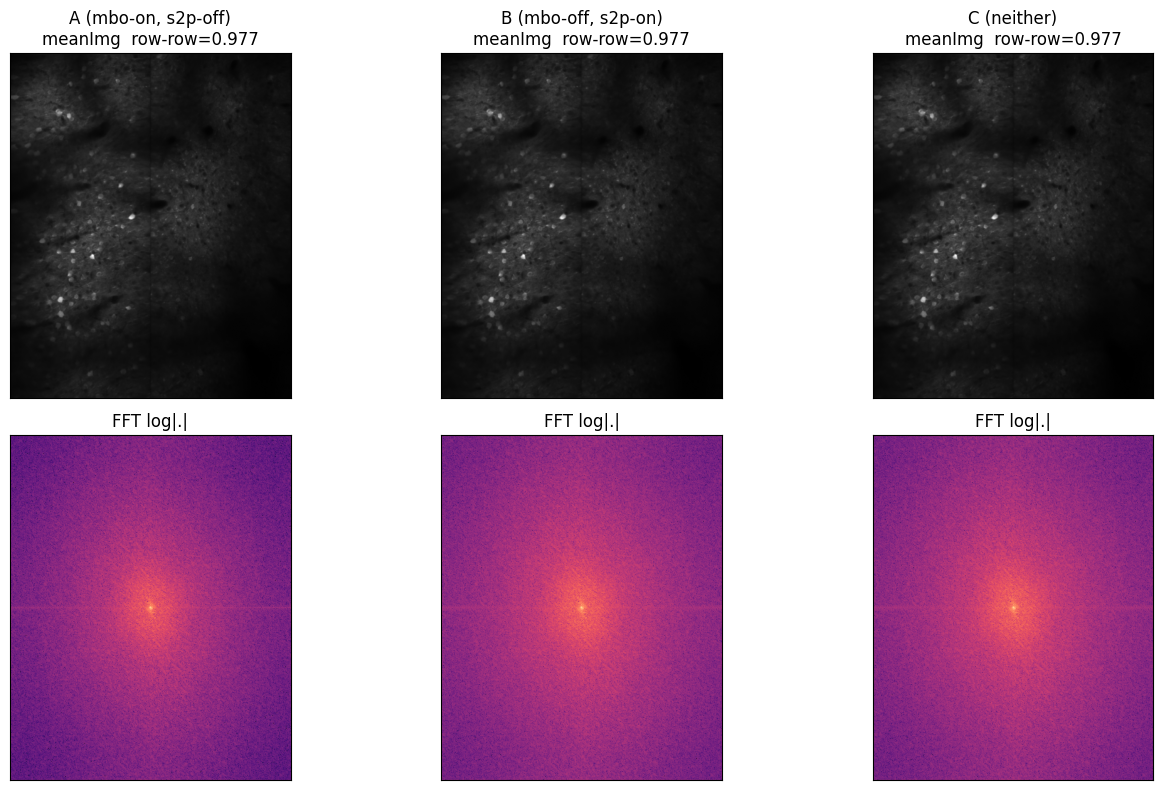

In [13]:
# show the meanImg and its FFT for each run
fig, ax = plt.subplots(2, 3, figsize=(14, 8))
for j, (name, r) in enumerate(runs.items()):
    mi = r["ops"]["meanImg"]
    med, _ = row_row_corr(mi)
    ax[0, j].imshow(mi, cmap="gray")
    ax[0, j].set_title(f"{name}\nmeanImg  row-row={med:.3f}")
    ax[1, j].imshow(fft_log_mag(mi), cmap="magma")
    ax[1, j].set_title("FFT log|.|")
    for a in (ax[0,j], ax[1,j]): a.set_xticks([]); a.set_yticks([])
plt.tight_layout(); plt.show()

In [14]:
# match cells across runs by nearest centroid, restricted to iscell
from scipy.spatial import cKDTree

MATCH_RADIUS = 3.0  # pixels

refA = runs["A (mbo-on, s2p-off)"]
ids_A = np.where(refA["iscell"])[0]
cents_A = refA["centroids"][ids_A]

def nn_map(target_run):
    ids_t = np.where(target_run["iscell"])[0]
    if len(ids_t) == 0:
        return np.full(len(ids_A), -1, dtype=int)
    tree = cKDTree(target_run["centroids"][ids_t])
    d, j = tree.query(cents_A, k=1, distance_upper_bound=MATCH_RADIUS)
    out = np.where(np.isfinite(d), ids_t[np.clip(j, 0, len(ids_t)-1)], -1)
    out[~np.isfinite(d)] = -1
    return out

map_B = nn_map(runs["B (mbo-off, s2p-on)"])
map_C = nn_map(runs["C (neither)"])

matched = np.where((map_B >= 0) & (map_C >= 0))[0]
print(f"cells matched across all 3 runs: {len(matched)} / {len(ids_A)}")

cells matched across all 3 runs: 43 / 48


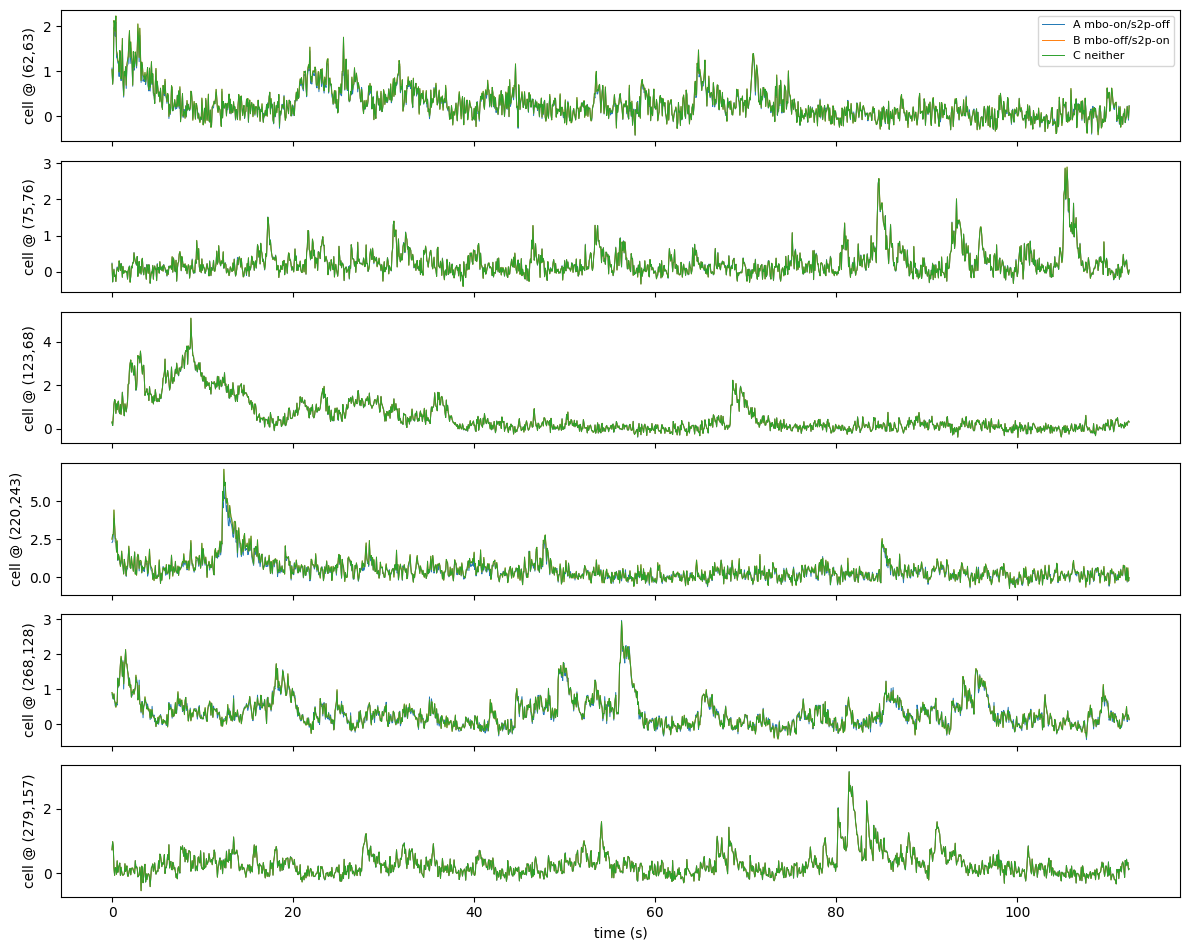

In [15]:
# trace comparison for N matched cells
N_CELLS = min(6, len(matched))
neuropil_coef = 0.7

def dff(F, Fneu, baseline_pct=20):
    x = F - neuropil_coef * Fneu
    b = np.percentile(x, baseline_pct, axis=1, keepdims=True)
    b = np.where(b <= 0, np.abs(b) + 1, b)
    return (x - b) / b

fs = runs["A (mbo-on, s2p-off)"]["ops"].get("fs", 1.0)
fig, axes = plt.subplots(N_CELLS, 1, figsize=(12, 1.6 * N_CELLS), sharex=True)
if N_CELLS == 1: axes = [axes]

for k, idx_in_A in enumerate(matched[:N_CELLS]):
    roi_A = ids_A[idx_in_A]
    roi_B = map_B[idx_in_A]
    roi_C = map_C[idx_in_A]
    traces = {
        "A mbo-on/s2p-off": dff(runs["A (mbo-on, s2p-off)"]["F"][roi_A:roi_A+1],
                                runs["A (mbo-on, s2p-off)"]["Fneu"][roi_A:roi_A+1])[0],
        "B mbo-off/s2p-on": dff(runs["B (mbo-off, s2p-on)"]["F"][roi_B:roi_B+1],
                                runs["B (mbo-off, s2p-on)"]["Fneu"][roi_B:roi_B+1])[0],
        "C neither":       dff(runs["C (neither)"]["F"][roi_C:roi_C+1],
                                runs["C (neither)"]["Fneu"][roi_C:roi_C+1])[0],
    }
    n = min(len(t) for t in traces.values())
    t = np.arange(n) / fs
    for label, tr in traces.items():
        axes[k].plot(t, tr[:n], lw=0.7, label=label)
    cy, cx = refA["centroids"][roi_A]
    axes[k].set_ylabel(f"cell @ ({cy:.0f},{cx:.0f})")
    if k == 0: axes[k].legend(loc="upper right", fontsize=8)
axes[-1].set_xlabel("time (s)")
plt.tight_layout(); plt.show()

mean corr  A~B = 0.998
mean corr  A~C = 0.998
mean corr  B~C = 1.000


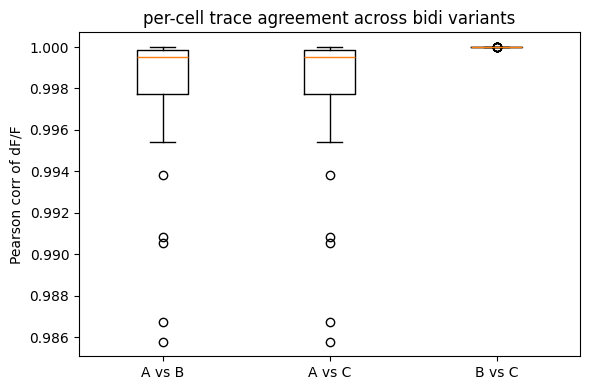

In [16]:
# pairwise trace correlation across the 3 variants for all matched cells
def pairwise_corr(x, y):
    n = min(len(x), len(y))
    x = x[:n] - x[:n].mean(); y = y[:n] - y[:n].mean()
    return float((x*y).sum() / (np.sqrt((x*x).sum() * (y*y).sum()) + 1e-12))

rows = []
for idx_in_A in matched:
    rA = ids_A[idx_in_A]; rB = map_B[idx_in_A]; rC = map_C[idx_in_A]
    fA = dff(runs["A (mbo-on, s2p-off)"]["F"][rA:rA+1], runs["A (mbo-on, s2p-off)"]["Fneu"][rA:rA+1])[0]
    fB = dff(runs["B (mbo-off, s2p-on)"]["F"][rB:rB+1], runs["B (mbo-off, s2p-on)"]["Fneu"][rB:rB+1])[0]
    fC = dff(runs["C (neither)"]["F"][rC:rC+1],         runs["C (neither)"]["Fneu"][rC:rC+1])[0]
    rows.append([pairwise_corr(fA, fB), pairwise_corr(fA, fC), pairwise_corr(fB, fC)])
corr_mat = np.asarray(rows)

print(f"mean corr  A~B = {corr_mat[:,0].mean():.3f}")
print(f"mean corr  A~C = {corr_mat[:,1].mean():.3f}")
print(f"mean corr  B~C = {corr_mat[:,2].mean():.3f}")

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax.boxplot(corr_mat, labels=["A vs B", "A vs C", "B vs C"])
ax.set_ylabel("Pearson corr of dF/F")
ax.set_title("per-cell trace agreement across bidi variants")
plt.tight_layout(); plt.show()